# Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Data Load and Preprocessing

In [46]:
df = pd.read_csv("diabetes.csv")
X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

## Part A: Clustering

### 1.)

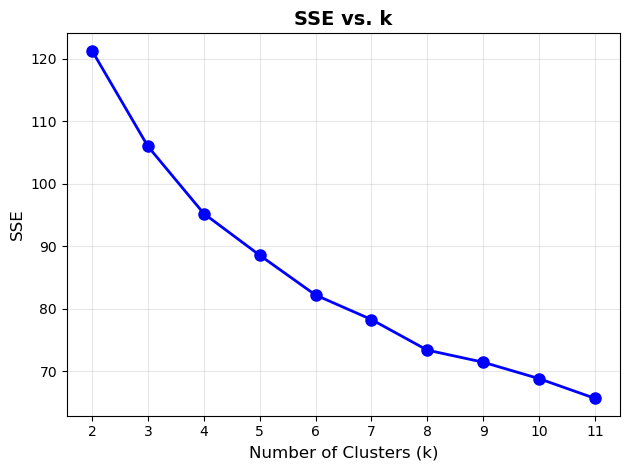

In [ ]:
k_values = range(2, 12)
max_iter = 500
sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(k_values, sse, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.title('SSE vs. k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### 2.)

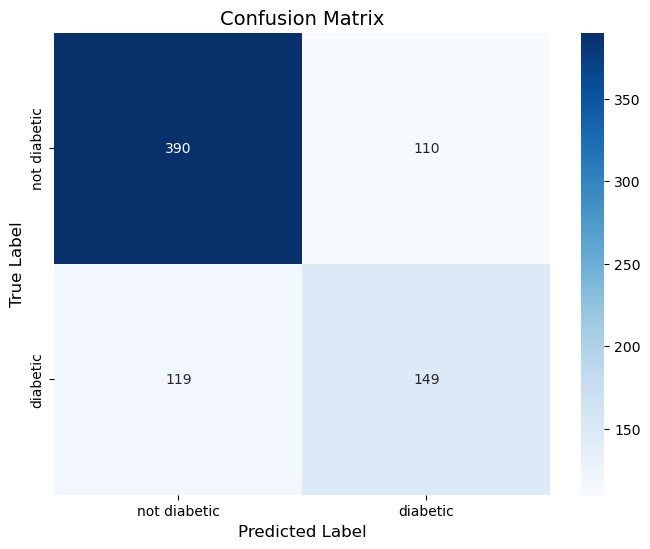


Accuracy:  0.7018229166666666
Precision: 0.5752895752895753
Recall:    0.5559701492537313
F1-score:  0.5654648956356736


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, max_iter=max_iter)
cluster_labels = kmeans.fit_predict(X_scaled)

y_cluster_labels = pd.DataFrame({"Cluster": cluster_labels, "TrueOutcome": y})
cluster_outcomes = (y_cluster_labels.groupby("Cluster")["TrueOutcome"].
                    agg(lambda x: x.value_counts().idxmax()))
y_pred = y_cluster_labels["Cluster"].map(cluster_outcomes)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["not diabetic", "diabetic"],
            yticklabels=["not diabetic", "diabetic"])
plt.title(f"Confusion Matrix", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.show()

print(f"\nAccuracy:  {acc}")
print(f"Precision: {prec}")
print(f"Recall:    {rec}")
print(f"F1-score:  {f1}")

### 3.)

In [ ]:
print("Class distribution and purity per cluster:")
print("=" * 60)
cluster_labels_count = pd.crosstab(kmeans.labels_, y, rownames=["Cluster"], colnames=["TrueOutcome"])
cluster_labels_count.columns = ["not diabetic", "diabetic"]

purity = cluster_labels_count.max(axis=1) / cluster_labels_count.sum(axis=1)
cluster_purity = pd.concat([cluster_labels_count, purity], axis=1)
cluster_purity.columns = ["not diabetic", "diabetic", "Purity"]
print(cluster_purity)

print("\nCluster centers:")
print("=" * 60)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
print(centers.to_string())

Class distribution and purity per cluster:
         not diabetic  diabetic    Purity
Cluster                                  
0                  61        73  0.544776
1                 254        26  0.907143
2                  43        26  0.623188
3                  19        16  0.542857
4                  74        51  0.592000
5                  49        76  0.608000

Cluster centers:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin        BMI  DiabetesPedigreeFunction        Age
0     1.880597  149.470149   7.447015e+01      34.194030  209.574627  37.071642                  0.623627  29.126866
1     1.767857   99.103571   6.696429e+01      23.635714   58.585714  30.020714                  0.424464  25.185714
2     5.956522  135.202899   8.040580e+01       5.115942    8.130435  29.518841                  0.403594  56.811594
3     3.628571  117.800000   1.354472e-14       1.514286    0.000000  25.705714                  0.388429  30.714286
4     4.816000  12

## Part B: PCA

### 1.)

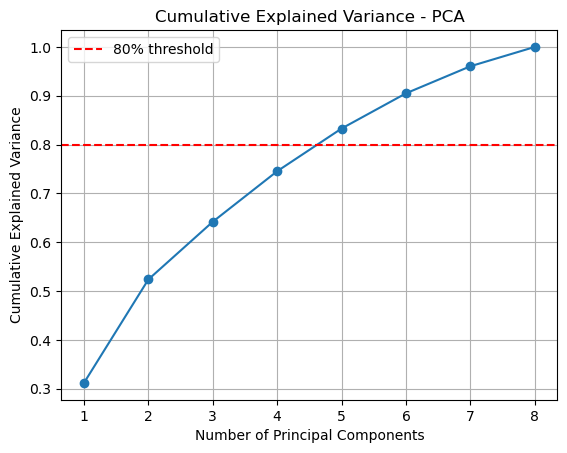

In [37]:
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.8, color="r", linestyle="--",label ="80% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance - PCA")
plt.grid(True)
plt.savefig("cumulative_variance.png")
plt.legend()
plt.show()

### 2.)

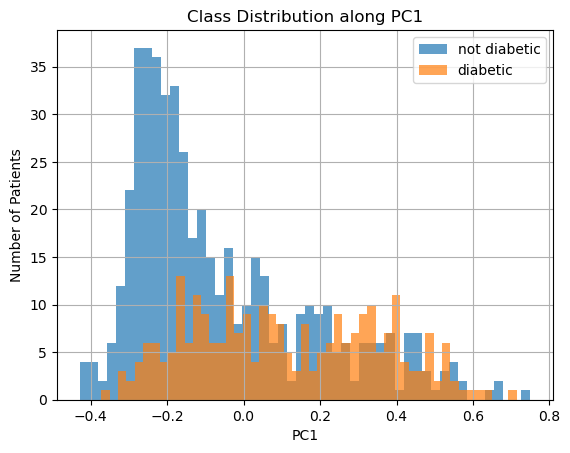

In [54]:
pc1 = X_pca[:, 0]
pca_df = pd.DataFrame({"PC1": pc1, "Outcome": y})

plt.hist(pca_df[pca_df["Outcome"]==0]["PC1"], bins=50, alpha=0.7, label="not diabetic")
plt.hist(pca_df[pca_df["Outcome"]==1]["PC1"], bins=50, alpha=0.7, label="diabetic")
plt.xlabel("PC1")
plt.ylabel("Number of Patients")
plt.title("Class Distribution along PC1")
plt.legend()
plt.grid(True)
plt.show()

### 3.)

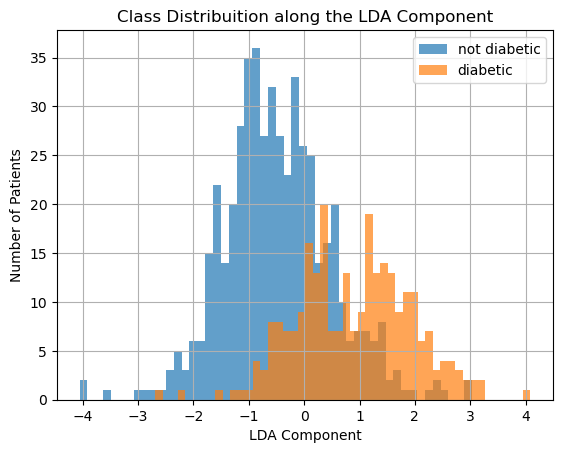

In [57]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.hist(X_lda[y == 0], bins=50, alpha=0.7, label="not diabetic")
plt.hist(X_lda[y == 1], bins=50, alpha=0.7, label="diabetic")
plt.xlabel("LDA Component")
plt.ylabel("Number of Patients")
plt.title("Class Distribuition along the LDA Component")
plt.legend()
plt.grid(True)
plt.show()